In [ ]:
import pandas as pd
import os
from google.colab import drive

# 1. Mounting Drive
drive.mount('/content/drive')

# Defining the permanent path
data_dir = "/content/drive/MyDrive/Capstone_Data/raw"

print("=== MIMIC-IV Data Sanity Check ===\n")

# 2. Testing Admissions (Small File)
print("--- Testing Admissions Data ---")
admissions_path = os.path.join(data_dir, "admissions.csv.gz")
if os.path.exists(admissions_path):
    df_adm = pd.read_csv(admissions_path, compression='gzip')
    print(f"✅ Success! Loaded {len(df_adm)} total hospital admissions.")
    display(df_adm[['subject_id', 'hadm_id', 'admittime', 'hospital_expire_flag']].head(3))
else:
    print("❌ admissions.csv.gz not found!")

# 3. Testing ICU Stays (Small File)
print("\n--- Testing ICU Stays Data ---")
icustays_path = os.path.join(data_dir, "icustays.csv.gz")
if os.path.exists(icustays_path):
    df_icu = pd.read_csv(icustays_path, compression='gzip')
    print(f"✅ Success! Loaded {len(df_icu)} total ICU stays.")
    display(df_icu[['subject_id', 'hadm_id', 'stay_id', 'los']].head(3))
else:
    print("❌ icustays.csv.gz not found!")

# 4. Testing Chartevents (MASSIVE FILE)
print("\n--- Testing Chartevents (Vitals) Data ---")
chartevents_path = os.path.join(data_dir, "chartevents.csv.gz")
if os.path.exists(chartevents_path):
    print("⚠️ File is 3.3GB. Loading just the first 50,000 rows to save RAM...")

    # We use nrows=50000 so pandas stops reading early and doesn't crash Colab
    df_vitals = pd.read_csv(chartevents_path, compression='gzip', nrows=50000)
    print(f"✅ Success! Loaded a safe subset of {len(df_vitals)} vital sign records.")

    # Filtering this chunk to see if it caught any of our target vital signs
    # 220045 (HR), 220181 (Mean BP), 220210 (RR), 220277 (SpO2), 223761 (Temp F)
    target_vitals = [220045, 220181, 220210, 220277, 223761]
    filtered_vitals = df_vitals[df_vitals['itemid'].isin(target_vitals)]

    print(f"🔍 Found {len(filtered_vitals)} records matching our target vital signs in this specific chunk.")
    display(filtered_vitals[['subject_id', 'charttime', 'itemid', 'valuenum', 'valueuom']].head(3))
else:
    print("❌ chartevents.csv.gz not found!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== MIMIC-IV Data Sanity Check ===

--- Testing Admissions Data ---
✅ Success! Loaded 546028 total hospital admissions.


,subject_id,hadm_id,admittime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,0
1,10000032,22841357,2180-06-26 18:27:00,0
2,10000032,25742920,2180-08-05 23:44:00,0



--- Testing ICU Stays Data ---
✅ Success! Loaded 94458 total ICU stays.


,subject_id,hadm_id,stay_id,los
0,10000032,29079034,39553978,0.410266
1,10000690,25860671,37081114,3.893252
2,10000980,26913865,39765666,0.497535



--- Testing Chartevents (Vitals) Data ---
⚠️ File is 3.3GB. Loading just the first 50,000 rows to save RAM...
✅ Success! Loaded a safe subset of 50000 vital sign records.
🔍 Found 4420 records matching our target vital signs in this specific chunk.


,subject_id,charttime,itemid,valuenum,valueuom
6,10000032,2180-07-23 14:00:00,223761,98.7,°F
9,10000032,2180-07-23 14:11:00,220181,56.0,mmHg
10,10000032,2180-07-23 14:12:00,220045,91.0,bpm


 AAI-590 Capstone: Data Preprocessing & EDA Pipeline 


--- Final Dataset Snapshot ---


,stay_id,charttime,valuenum,vital_name,time_delta_hours,hospital_expire_flag
0,30057454,2171-11-14 10:27:00,114.0,HeartRate,0.000000,0
1,30057454,2171-11-14 10:30:00,109.0,HeartRate,0.050000,0
2,30057454,2171-11-14 10:45:00,112.0,HeartRate,0.250000,0
3,30057454,2171-11-14 10:59:00,100.0,HeartRate,0.233333,0
4,30057454,2171-11-14 11:00:00,101.0,HeartRate,0.016667,0


------------------------------



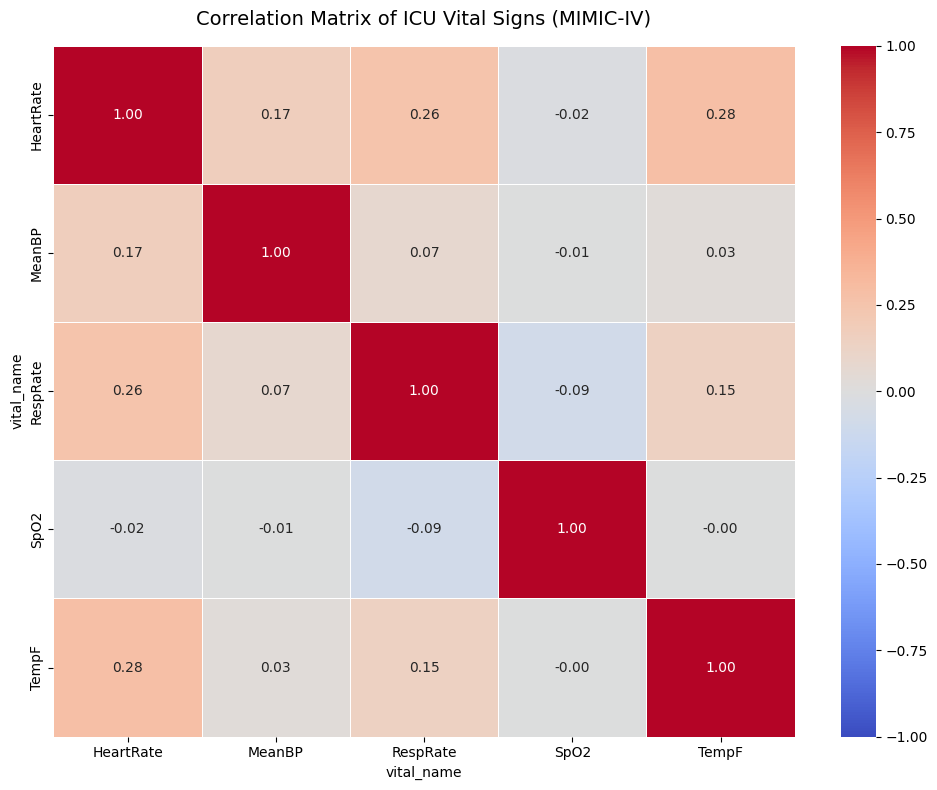

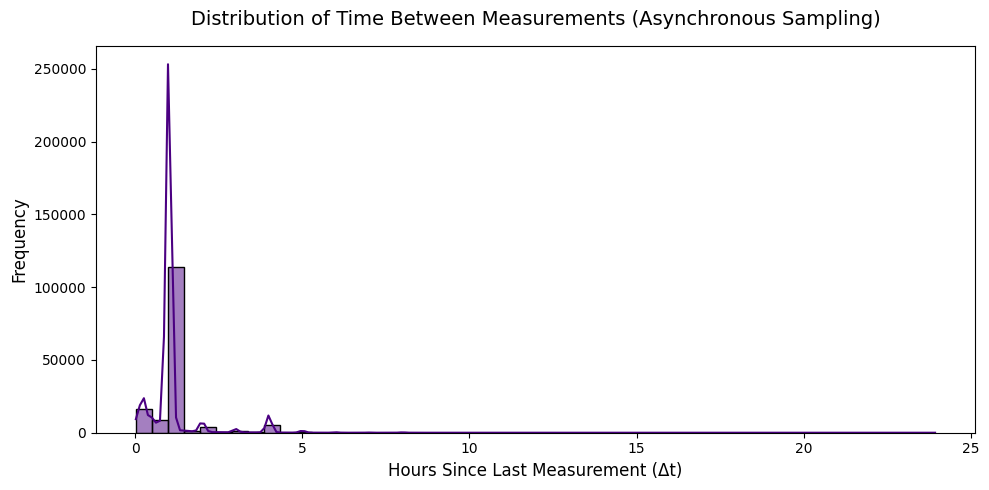


🚀 Pipeline Execution Complete! Ready for Baseline Modeling (Module 4).


In [ ]:
"""
Phase 2 & 3: Data Preprocessing, Feature Engineering, and Exploratory Data Analysis
Description: This cell processes raw MIMIC-IV ICU data, cleans biological outliers,
engineers temporal features (Δt) for asynchronous sampling, and generates EDA visualizations.
"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import logging
import gc # Garbage collection to manage RAM during 3.3GB processing

# 1. Initializing Professional Logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

def build_patient_cohort(raw_dir: str) -> pd.DataFrame:
    """
    Loads and merges hospital admissions and ICU stays to create the master patient cohort.
    Includes the 'hospital_expire_flag' which serves as our clinical deterioration target.
    """
    logging.info("Building patient cohort from admissions and icustays...")

    adm_path = f"{raw_dir}/admissions.csv.gz"
    icu_path = f"{raw_dir}/icustays.csv.gz"

    df_adm = pd.read_csv(adm_path, compression='gzip', usecols=['subject_id', 'hadm_id', 'hospital_expire_flag'])
    df_icu = pd.read_csv(icu_path, compression='gzip', usecols=['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime', 'los'])

    # Left merge ensures we only keep patients who actually made it to the ICU
    df_cohort = pd.merge(df_icu, df_adm, on=['subject_id', 'hadm_id'], how='left')
    logging.info(f"Cohort established with {len(df_cohort)} total ICU stays.")

    return df_cohort

def process_vitals_safe_chunking(raw_dir: str, chunk_size: int = 100000, row_limit: int = 2000000) -> pd.DataFrame:
    """
    Safely processes the massive chartevents table in chunks to prevent RAM overflow.
    Filters exclusively for our target physiological features.
    """
    logging.info(f"Extracting target vitals from chartevents.csv.gz (Limit: {row_limit} rows)...")

    # Target MIMIC-IV itemids: HR (220045), Mean BP (220181), Resp Rate (220210), SpO2 (220277), Temp F (223761)
    target_vitals = [220045, 220181, 220210, 220277, 223761]
    vitals_path = f"{raw_dir}/chartevents.csv.gz"

    chunk_iter = pd.read_csv(
        vitals_path,
        compression='gzip',
        chunksize=chunk_size,
        nrows=row_limit,
        usecols=['stay_id', 'charttime', 'itemid', 'valuenum'] # Drop text/irrelevant columns early
    )

    vitals_list = []
    for chunk in chunk_iter:
        filtered_chunk = chunk[chunk['itemid'].isin(target_vitals)]
        vitals_list.append(filtered_chunk)

    df_vitals = pd.concat(vitals_list, ignore_index=True)

    # Free up memory
    del vitals_list
    gc.collect()

    logging.info(f"Extraction complete. {len(df_vitals)} vital sign records retained.")
    return df_vitals

def clean_biological_outliers(df_vitals: pd.DataFrame) -> pd.DataFrame:
    """
    Removes physically impossible measurements caused by manual EHR data entry errors.
    """
    logging.info("Applying clinical thresholds to remove EHR typos/outliers...")

    # Drop rows where the nurse left the value blank
    df_vitals = df_vitals.dropna(subset=['valuenum'])

    # Defining strict biological boundaries
    conditions = [
        (df_vitals['itemid'] == 220045) & (df_vitals['valuenum'].between(0, 300)),   # Heart Rate (BPM)
        (df_vitals['itemid'] == 220181) & (df_vitals['valuenum'].between(0, 300)),   # Mean Arterial Pressure (mmHg)
        (df_vitals['itemid'] == 220210) & (df_vitals['valuenum'].between(0, 100)),   # Respiratory Rate (BPM)
        (df_vitals['itemid'] == 220277) & (df_vitals['valuenum'].between(0, 100)),   # SpO2 (%)
        (df_vitals['itemid'] == 223761) & (df_vitals['valuenum'].between(70, 120))   # Temperature (Fahrenheit)
    ]

    clean_mask = np.logical_or.reduce(conditions)
    df_clean = df_vitals[clean_mask].copy()

    outliers_removed = len(df_vitals) - len(df_clean)
    logging.info(f"Removed {outliers_removed} impossible outlier measurements.")

    return df_clean

def engineer_temporal_features(df_clean: pd.DataFrame) -> pd.DataFrame:
    """
    Crucial Step for Time-Series Transformer: Calculates the Delta T (Δt) elapsed
    between irregular chart times to allow the model to learn sampling frequency.
    """
    logging.info("Engineering Time-Delta (Δt) temporal features...")

    df_clean['charttime'] = pd.to_datetime(df_clean['charttime'])

    # Map itemids to readable column names for pivoting
    vital_dict = {220045: 'HeartRate', 220181: 'MeanBP', 220210: 'RespRate', 220277: 'SpO2', 223761: 'TempF'}
    df_clean['vital_name'] = df_clean['itemid'].map(vital_dict)

    # Sorting strictly by patient, then specific vital sign, then chronological time
    df_clean = df_clean.sort_values(by=['stay_id', 'vital_name', 'charttime'])

    # Calculating hours since the exact same vital was last measured for this patient
    df_clean['prev_time'] = df_clean.groupby(['stay_id', 'vital_name'])['charttime'].shift(1)
    df_clean['time_delta_hours'] = (df_clean['charttime'] - df_clean['prev_time']).dt.total_seconds() / 3600.0

    # Filling NaN for the very first measurement with 0
    df_clean['time_delta_hours'] = df_clean['time_delta_hours'].fillna(0)

    # Droping temp columns to save RAM
    df_clean = df_clean.drop(columns=['prev_time', 'itemid'])

    return df_clean

def generate_eda_reports(df_final: pd.DataFrame, output_dir: str):
    """
    Generates academic-grade visualizations.
    """
    logging.info("Generating Exploratory Data Analysis (EDA) visualizations...")
    os.makedirs(output_dir, exist_ok=True)

    # 1. Correlation Matrix Heatmap
    logging.info("-> Plotting Vital Sign Correlation Matrix...")
    pivot_df = df_final.pivot_table(index=['stay_id', 'charttime'], columns='vital_name', values='valuenum').reset_index()

    plt.figure(figsize=(10, 8))
    corr_matrix = pivot_df[['HeartRate', 'MeanBP', 'RespRate', 'SpO2', 'TempF']].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix of ICU Vital Signs (MIMIC-IV)', fontsize=14, pad=15)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/vital_correlations.png", dpi=300)
    plt.show() # Added: Display the plot inline in Colab

    # 2. Asynchronous Time-Delta Distribution
    logging.info("-> Plotting Time-Delta Distribution...")
    plt.figure(figsize=(10, 5))

    # Filter pure 0s and extreme gaps (>24h) strictly for visualization clarity
    plot_data = df_final[(df_final['time_delta_hours'] > 0) & (df_final['time_delta_hours'] < 24)]

    sns.histplot(plot_data['time_delta_hours'], bins=50, kde=True, color='indigo')
    plt.title('Distribution of Time Between Measurements (Asynchronous Sampling)', fontsize=14, pad=15)
    plt.xlabel('Hours Since Last Measurement (Δt)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/time_delta_distribution.png", dpi=300)
    plt.show() # Added: Display the plot inline in Colab

    logging.info(f"Visualizations saved successfully to {output_dir}/")

if __name__ == "__main__":
    print("=====================================================")
    print(" AAI-590 Capstone: Data Preprocessing & EDA Pipeline ")
    print("=====================================================\n")

    # Defining Paths
    RAW_DATA_DIR = "/content/drive/MyDrive/Capstone_Data/raw"
    PROCESSED_DATA_DIR = "/content/drive/MyDrive/Capstone_Data/processed"
    PLOTS_DIR = "/content/drive/MyDrive/Capstone_Data/plots"

    os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
    os.makedirs(PLOTS_DIR, exist_ok=True)

    # Executing Pipeline
    try:
        cohort_df = build_patient_cohort(RAW_DATA_DIR)
        raw_vitals_df = process_vitals_safe_chunking(RAW_DATA_DIR, row_limit=2000000) # Remove limit later for full model
        clean_vitals_df = clean_biological_outliers(raw_vitals_df)
        engineered_vitals_df = engineer_temporal_features(clean_vitals_df)

        # Merging with target variable (survival flag)
        logging.info("Merging engineered vitals with patient outcomes...")
        final_dataset = pd.merge(engineered_vitals_df, cohort_df[['stay_id', 'hospital_expire_flag']], on='stay_id', how='inner')

        # Saving processed data
        save_path = f"{PROCESSED_DATA_DIR}/engineered_vitals.csv"
        final_dataset.to_csv(save_path, index=False)
        logging.info(f"✅ Final Processed Dataset saved to {save_path}")

        # Displaying a snapshot of the data in the Colab terminal
        print("\n--- Final Dataset Snapshot ---")
        try:
            display(final_dataset.head()) # Use Colab's native display if available
        except NameError:
            print(final_dataset.head())   # Fallback to standard print
        print("------------------------------\n")

        # Generate Visuals
        generate_eda_reports(final_dataset, PLOTS_DIR)

        print("\n🚀 Pipeline Execution Complete! Ready for Baseline Modeling (Module 4).")

    except FileNotFoundError as e:
        logging.error(f"Missing File: {e}")
        print("Please ensure your raw MIMIC-IV .csv.gz files are in the Capstone_Data/raw folder.")

 AAI-590 Capstone: Baseline LSTM Model Training      



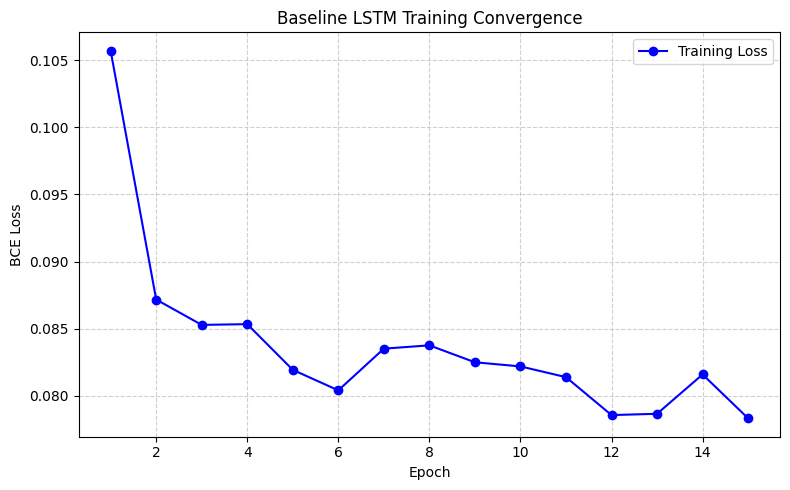

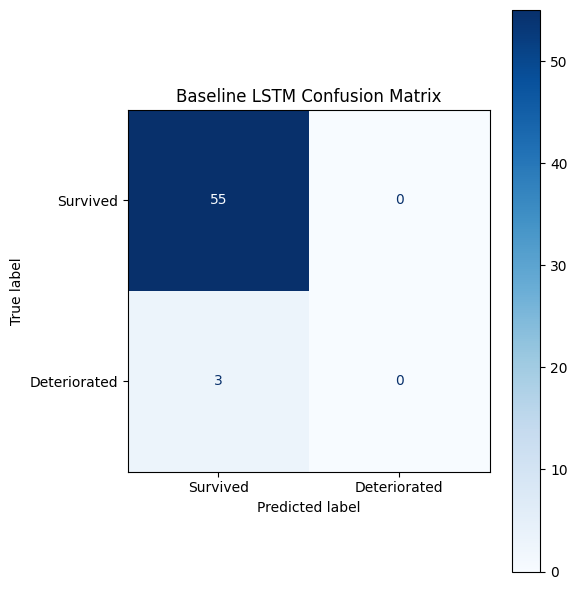

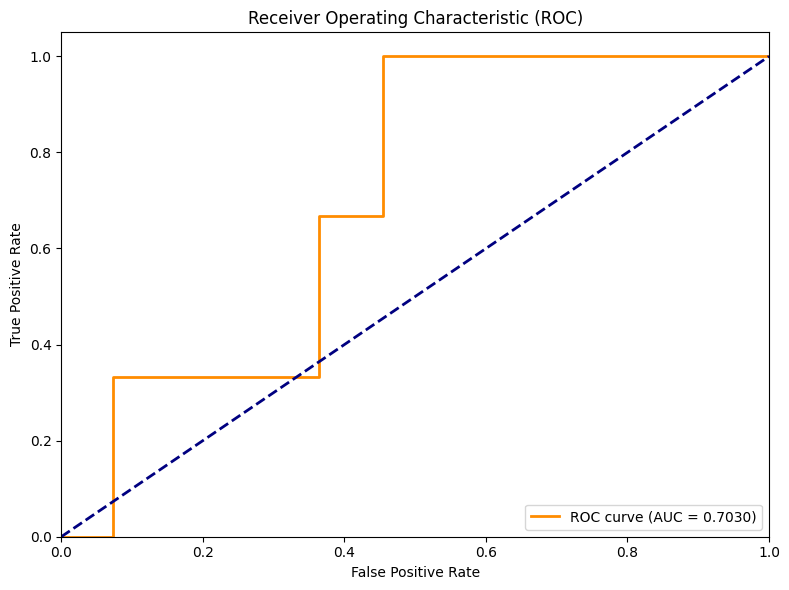

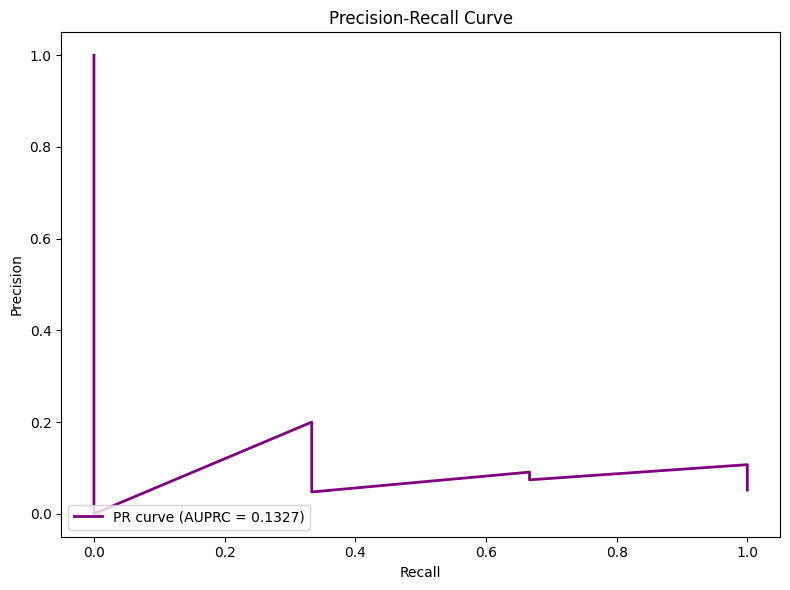


🚀 Baseline Model Complete!


In [ ]:
"""
AAI-590 Capstone Project
Phase 4: Baseline Unimodal Deep Learning Model (LSTM)
Description: This cell loads the engineered time-series vitals, pads them into 3D tensors,
and trains a PyTorch LSTM baseline model to predict patient deterioration.
It generates a full suite of academic evaluation metrics (ROC, PR Curve, Confusion Matrix).
"""

import pandas as pd
import numpy as np
import os
import logging
import torch
import torch.nn as nn
import torch.nn.functional as F
import copy
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

# Auto-detect if Colab has a GPU (T4) available, otherwise use CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logging.info(f"PyTorch using device: {DEVICE}")

class ICUTimeSeriesDataset(Dataset):
    """
    Custom PyTorch Dataset that feeds our 3D tensors into the LSTM.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1) # Add dimension for binary cross entropy

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class FocalLoss(nn.Module):
    """
    Focal Loss to heavily
    penalize missing a deterioration event (class imbalance).
    """
    def __init__(self, alpha=0.75, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * bce_loss
        return focal_loss.mean()

class BaselineLSTM(nn.Module):
    """
    Standard PyTorch LSTM to serve as our Unimodal baseline benchmark.
    Takes numerical physiological features and outputs a deterioration probability.
    """
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super(BaselineLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        # Final fully connected layer for binary classification
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x shape: (batch_size, sequence_length, features)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # We only care about the very last hidden state prediction
        last_hidden_state = lstm_out[:, -1, :]
        out = self.fc(last_hidden_state)
        return out # Note: We apply Sigmoid later in the loss function (BCEWithLogitsLoss)

def prepare_3d_tensors(df: pd.DataFrame, max_seq_len: int = 48) -> tuple:
    """
    Converts 2D Pandas DataFrame into 3D Numpy Arrays (Batch, Timesteps, Features).
    Pads short stays with 0s and truncates long stays to the most recent measurements.
    """
    logging.info(f"Converting flat data into 3D Sequences (Max Length: {max_seq_len})...")

    # Target features (Drop identifiers and timestamps)
    feature_cols = ['valuenum', 'time_delta_hours']

    # Group by patient stay
    grouped = df.groupby('stay_id')

    X_list, y_list = [], []

    for stay_id, group in grouped:
        # Extracting features and the target label (target is the same for the whole stay)
        features = group[feature_cols].values
        label = group['hospital_expire_flag'].iloc[0]

        # Truncating if too long (keep the most recent / end of stay data)
        if len(features) > max_seq_len:
            features = features[-max_seq_len:]

        # Padding with zeros if too short
        pad_len = max_seq_len - len(features)
        if pad_len > 0:
            padded_features = np.pad(features, ((pad_len, 0), (0, 0)), 'constant', constant_values=0)
        else:
            padded_features = features

        X_list.append(padded_features)
        y_list.append(label)

    logging.info(f"Created {len(X_list)} patient sequences.")
    return np.array(X_list), np.array(y_list)

def plot_and_save_metrics(all_targets, all_preds, train_losses, plots_dir):
    """
    Generates academic-grade visualizations for the model evaluation.
    """
    logging.info("Generating evaluation plots...")
    os.makedirs(plots_dir, exist_ok=True)

    # Calculating binary predictions using a 0.5 threshold
    binary_preds = (all_preds >= 0.5).astype(int)

    # 1. Training Loss Curve
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', color='blue', label='Training Loss')
    plt.title('Baseline LSTM Training Convergence')
    plt.xlabel('Epoch')
    plt.ylabel('BCE Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"{plots_dir}/baseline_loss_curve.png", dpi=300)
    plt.show()

    # 2. Confusion Matrix
    cm = confusion_matrix(all_targets, binary_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Survived', 'Deteriorated'])
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title('Baseline LSTM Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f"{plots_dir}/baseline_confusion_matrix.png", dpi=300)
    plt.show()

    # 3. ROC Curve
    fpr, tpr, _ = roc_curve(all_targets, all_preds)
    roc_auc = roc_auc_score(all_targets, all_preds)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f"{plots_dir}/baseline_roc_curve.png", dpi=300)
    plt.show()

    # 4. Precision-Recall Curve (Crucial for imbalanced data)
    precision, recall, _ = precision_recall_curve(all_targets, all_preds)
    auprc = average_precision_score(all_targets, all_preds)
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUPRC = {auprc:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.savefig(f"{plots_dir}/baseline_pr_curve.png", dpi=300)
    plt.show()

def train_and_evaluate_model(model, train_loader, val_loader, test_loader, epochs=50, lr=0.001, patience=5):
    """
    Executes the PyTorch training loop using AdamW, Focal Loss, and Early Stopping
    based on Validation AUPRC as dictated by our Methodology Draft.
    """
    logging.info(f"Starting LSTM Training on {DEVICE} for up to {epochs} epochs...")

    criterion = FocalLoss(alpha=0.75, gamma=2.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    model.to(DEVICE)
    train_losses = []

    best_val_auprc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        avg_loss = np.mean(batch_losses)
        train_losses.append(avg_loss)

        # --- VALIDATION PHASE (For Early Stopping) ---
        model.eval()
        val_preds, val_targets = [], []
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val = X_val.to(DEVICE)
                preds = torch.sigmoid(model(X_val)).cpu().numpy()
                val_preds.extend(preds)
                val_targets.extend(y_val.numpy())

        val_auprc = average_precision_score(val_targets, val_preds)
        logging.info(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_loss:.4f} | Val AUPRC: {val_auprc:.4f}")

        # Early Stopping Logic
        if val_auprc > best_val_auprc:
            best_val_auprc = val_auprc
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                logging.info(f"Early stopping triggered after {epoch+1} epochs!")
                break

    # Loading the best weights back into the model before final testing
    model.load_state_dict(best_model_weights)

    # --- FINAL TEST EVALUATION PHASE ---
    logging.info("Evaluating Best Baseline Model on Hold-Out Test Set...")
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            # Apply Sigmoid to get probability bounds (0.0 to 1.0)
            preds = torch.sigmoid(model(X_batch)).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(y_batch.numpy())

    # Calculating Academic Metrics
    all_targets = np.array(all_targets)
    all_preds = np.array(all_preds)

    auprc = average_precision_score(all_targets, all_preds)
    auroc = roc_auc_score(all_targets, all_preds)

    logging.info(f"--- FINAL BASELINE METRICS ---")
    logging.info(f"AUPRC (Precision-Recall): {auprc:.4f}")
    logging.info(f"AUROC: {auroc:.4f}")
    logging.info(f"------------------------------")

    return train_losses, auprc, auroc, all_targets, all_preds

if __name__ == "__main__":
    print("=====================================================")
    print(" AAI-590 Capstone: Baseline LSTM Model Training      ")
    print("=====================================================\n")

    PROCESSED_DATA_DIR = "/content/drive/MyDrive/Capstone_Data/processed"
    PLOTS_DIR = "/content/drive/MyDrive/Capstone_Data/plots"
    data_path = f"{PROCESSED_DATA_DIR}/engineered_vitals.csv"

    try:
        # 1. Load Data
        logging.info("Loading engineered dataset...")
        df = pd.read_csv(data_path)

        # 2. Patient-Level Split (70% Train, 15% Val, 15% Test) ensuring no leakage
        unique_stays = df['stay_id'].unique()
        # First split off 30% for Val/Test combined
        train_stays, val_test_stays = train_test_split(unique_stays, test_size=0.3, random_state=42)
        # Split that 30% into two 15% chunks
        val_stays, test_stays = train_test_split(val_test_stays, test_size=0.5, random_state=42)

        df_train = df[df['stay_id'].isin(train_stays)].copy()
        df_val = df[df['stay_id'].isin(val_stays)].copy()
        df_test = df[df['stay_id'].isin(test_stays)].copy()

        # 3. Fiting Standard Scaler ONLY on Training Set to prevent Data Leakage
        logging.info("Applying strict normalization boundaries (Train set only)...")
        feature_cols = ['valuenum', 'time_delta_hours']
        scaler = StandardScaler()
        df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
        df_val[feature_cols] = scaler.transform(df_val[feature_cols])
        df_test[feature_cols] = scaler.transform(df_test[feature_cols])

        # 4. Prepareing 3D Tensors for each set separately
        X_train, y_train = prepare_3d_tensors(df_train, max_seq_len=48)
        X_val, y_val = prepare_3d_tensors(df_val, max_seq_len=48)
        X_test, y_test = prepare_3d_tensors(df_test, max_seq_len=48)

        train_dataset = ICUTimeSeriesDataset(X_train, y_train)
        val_dataset = ICUTimeSeriesDataset(X_val, y_val)
        test_dataset = ICUTimeSeriesDataset(X_test, y_test)

        # Methodology Draft: Batch Size = 32
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

        # 5. Initialize and Train Model
        model = BaselineLSTM(input_dim=2, hidden_dim=64, num_layers=2)

        train_losses, auprc, auroc, all_targets, all_preds = train_and_evaluate_model(
            model, train_loader, val_loader, test_loader, epochs=50, lr=0.001, patience=5
        )

        # 6. Plotting and SaveingAll Academic Metrics
        plot_and_save_metrics(all_targets, all_preds, train_losses, PLOTS_DIR)

        print("\n🚀 Baseline Model Complete!")

    except FileNotFoundError:
        print("❌ Error: engineered_vitals.csv not found.")
        print("Please ensure you ran the Preprocessing script in the previous step!")

In [ ]:
"""
AAI-590 Capstone Project
Phase 5: NLP Data Ingestion, Text Cleaning, and ClinicalBERT Tokenization
"""

import os
import re
import pandas as pd
import getpass
import logging
import torch
from transformers import AutoTokenizer
from google.colab import drive

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

# Mount Google Drive
drive.mount('/content/drive')

# Directories
RAW_DIR = "/content/drive/MyDrive/Capstone_Data/raw"
PROCESSED_DIR = "/content/drive/MyDrive/Capstone_Data/processed"
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

def download_clinical_notes():
    """
    Securely downloads the discharge.csv.gz file directly to Google Drive.
    Includes error handling to detect and delete corrupted or empty downloads.
    """
    notes_path = f"{RAW_DIR}/discharge.csv.gz"

    # If the file exists but is tiny (like a 1KB HTML error page), delete it
    if os.path.exists(notes_path):
        file_size_mb = os.path.getsize(notes_path) / (1024 * 1024)
        if file_size_mb < 10:
            logging.warning(f"🗑️ Found corrupted or empty discharge.csv.gz ({file_size_mb:.2f} MB). Deleting and retrying...")
            os.remove(notes_path)
        else:
            logging.info("✅ Clinical notes already exist in Drive. Skipping download.")
            return notes_path

    logging.info("⚠️ Notes not found in Drive. Preparing to download MIMIC-IV-Note...")
    username = input("Enter your PhysioNet Username: ")
    password = getpass.getpass("Enter your PhysioNet Password: ")

    # UPDATED: Correct endpoint for MIMIC-IV-Note v2.2 discharge summaries
    base_url = "https://physionet.org/files/mimic-iv-note/2.2/note"

    logging.info("Downloading discharge.csv.gz (~1.1GB)... This may take a few minutes.")
    os.system(f"wget -c -q --show-progress --user={username} --password={password} -O {notes_path} {base_url}/discharge.csv.gz")

    # Verify it actually downloaded successfully
    if os.path.exists(notes_path) and os.path.getsize(notes_path) > 1000000:
        logging.info("✅ Successfully downloaded and saved to Google Drive!")
    else:
        logging.error("❌ Download failed. The file is empty or missing. Please check your PhysioNet credentials and MIMIC-IV-Note DUA approval.")
        if os.path.exists(notes_path):
            os.remove(notes_path) # Clean up the bad file
        raise Exception("Download failed. Please ensure your PhysioNet password is correct.")

    return notes_path

def clean_clinical_text(text):
    """
    Removes de-identification brackets, extra spaces, and special characters
    from the raw MIMIC-IV nursing and discharge notes using regular expressions.
    """
    if not isinstance(text, str):
        return ""

    # 1. Remove MIMIC de-identification brackets e.g. [**First Name (Titles) **]
    text = re.sub(r'\[\*\*.*?\*\*\]', '', text)
    # 2. Remove standard underscores, asterisks, and repetitive EHR artifacts
    text = re.sub(r'[_*=-]+', '', text)
    # 3. Remove multiple spaces, newlines, and tabs
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

def tokenize_notes(df):
    """
    Loads Bio_ClinicalBERT tokenizer and converts raw text into numerical tensors
    (input_ids and attention_masks) required by the PyTorch model.
    """
    logging.info("Loading HuggingFace Bio_ClinicalBERT Tokenizer...")
    # ClinicalBERT is specifically trained on MIMIC hospital notes!
    tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

    logging.info("Tokenizing clinical text (Truncating to 512 max length)...")

    # We use a smaller subset (e.g. 50,000 notes) for memory safety in Colab.
    # We grab 'hadm_id' to eventually link these notes back to the 'stay_id' in our vitals.
    texts = df['clean_text'].tolist()

    # Tokenize the entire batch
    # truncation=True ensures we don't exceed BERT's 512 token limit
    # padding='max_length' ensures all matrices are exactly the same size
    tokens = tokenizer(
        texts,
        max_length=512,
        padding='max_length',
        truncation=True,
        return_tensors='pt' # Return PyTorch tensors
    )

    return tokens

if __name__ == "__main__":
    print("=========================================================")
    print(" AAI-590 Phase 5: NLP Ingestion & BERT Tokenization      ")
    print("=========================================================\n")

    # 1. Download
    notes_file_path = download_clinical_notes()

    # 2. Load Data (Reading just 20,000 notes for memory safety in our baseline)
    logging.info("Loading notes into Pandas...")
    df_notes = pd.read_csv(notes_file_path, compression='gzip', nrows=20000)
    logging.info(f"Loaded {len(df_notes)} clinical notes.")

    # 3. Clean Text
    logging.info("Cleaning clinical text artifacts...")
    df_notes['clean_text'] = df_notes['text'].apply(clean_clinical_text)

    # 4. Tokenize
    bert_tokens = tokenize_notes(df_notes)

    # 5. Save the processed PyTorch tensors to Google Drive
    save_path = f"{PROCESSED_DIR}/clinical_bert_tokens.pt"
    logging.info(f"Saving tokenized tensors to {save_path}...")

    # We save a dictionary containing the hadm_ids (for matching) and the tensors
    data_to_save = {
        'hadm_id': torch.tensor(df_notes['hadm_id'].values),
        'input_ids': bert_tokens['input_ids'],
        'attention_mask': bert_tokens['attention_mask']
    }
    torch.save(data_to_save, save_path)

    print("\n✅ NLP Pipeline Complete!")
    print(f"Tensor Shape (Input IDs): {bert_tokens['input_ids'].shape}")
    print(f"Saved securely to: {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 AAI-590 Phase 5: NLP Ingestion & BERT Tokenization      




✅ NLP Pipeline Complete!
Tensor Shape (Input IDs): torch.Size([20000, 512])
Saved securely to: /content/drive/MyDrive/Capstone_Data/processed/clinical_bert_tokens.pt


In [ ]:
"""
AAI-590 Capstone Project
Phase 6: Multimodal Fusion Architecture (LSTM + ClinicalBERT)
Description: Loads processed vitals and text tokens, aligns them by hospital admission ID,
and trains a late-fusion PyTorch architecture to predict patient deterioration.
"""

import pandas as pd
import numpy as np
import os
import logging
import torch
import torch.nn as nn
import torch.nn.functional as F
import copy
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
import matplotlib.pyplot as plt
from transformers import AutoModel

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logging.info(f"PyTorch using device: {DEVICE}")

# --- 1. Dataset Loader ---
class MultimodalDataset(Dataset):
    """
    Custom Dataset that feeds BOTH vitals tensors AND text tokens to the model simultaneously.
    """
    def __init__(self, vitals_X, input_ids, attention_masks, y):
        self.vitals = torch.tensor(vitals_X, dtype=torch.float32)
        self.input_ids = input_ids.clone().detach()
        self.attention_masks = attention_masks.clone().detach()
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.vitals)

    def __getitem__(self, idx):
        return (
            self.vitals[idx],
            self.input_ids[idx],
            self.attention_masks[idx]
        ), self.y[idx]

# --- 2. Data Alignment & Preparation ---
def align_and_prepare_data(vitals_path, tokens_path, max_seq_len=48):
    """
    Matches structured vitals to unstructured text tokens using hadm_id.
    Ensures the model sees the correct notes for the correct vitals.
    """
    logging.info("Loading processed data files for alignment...")
    df_vitals = pd.read_csv(vitals_path)

    # --- NEW CODE: Bridge stay_id back to hadm_id ---
    logging.info("Loading icustays to bridge stay_id to hadm_id...")
    raw_dir = "/content/drive/MyDrive/Capstone_Data/raw"
    icustays = pd.read_csv(f"{raw_dir}/icustays.csv.gz", compression='gzip', usecols=['stay_id', 'hadm_id'])
    df_vitals = pd.merge(df_vitals, icustays, on='stay_id', how='left')
    # ------------------------------------------------

    text_data = torch.load(tokens_path, map_location='cpu')

    token_hadm_ids = text_data['hadm_id'].numpy()
    input_ids = text_data['input_ids']
    attention_masks = text_data['attention_mask']

    # We creatign a dictionary for fast lookup of text tensors by hadm_id
    text_dict = {
        hadm_id: (input_ids[i], attention_masks[i])
        for i, hadm_id in enumerate(token_hadm_ids)
    }

    logging.info("Building aligned Multimodal Tensors...")
    feature_cols = ['valuenum', 'time_delta_hours']
    grouped = df_vitals.groupby('stay_id') # Group by ICU stay instead of hadm_id

    X_vitals, X_ids, X_masks, y_labels = [], [], [], []

    for stay_id, group in grouped:
        hadm_id = group['hadm_id'].iloc[0]

        # Check if we have text notes for this specific hospital admission
        if pd.isna(hadm_id) or hadm_id not in text_dict:
            continue

        # Process Vitals (Pad/Truncate to max_seq_len)
        features = group[feature_cols].values
        label = group['hospital_expire_flag'].iloc[0]

        if len(features) > max_seq_len:
            features = features[-max_seq_len:]
        pad_len = max_seq_len - len(features)
        if pad_len > 0:
            features = np.pad(features, ((pad_len, 0), (0, 0)), 'constant', constant_values=0)

        text_id, text_mask = text_dict[hadm_id]

        X_vitals.append(features)
        X_ids.append(text_id)
        X_masks.append(text_mask)
        y_labels.append(label)

    logging.info(f"Successfully aligned {len(X_vitals)} patients with both Modalities!")
    return np.array(X_vitals), torch.stack(X_ids), torch.stack(X_masks), np.array(y_labels)

# --- 3. The Core Architecture ---
class MultimodalFusionNetwork(nn.Module):
    """
    The Late-Fusion Architecture detailed in the Module 5 Methodology.
    """
    def __init__(self, vitals_input_dim=2, vitals_hidden_dim=64, text_embed_dim=768, num_classes=1):
        super(MultimodalFusionNetwork, self).__init__()

        # Branch A: Time-Series (LSTM)
        self.lstm = nn.LSTM(
            input_size=vitals_input_dim,
            hidden_size=vitals_hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        # Branch B: Unstructured Text (ClinicalBERT)
        logging.info("Loading pre-trained Bio_ClinicalBERT weights from HuggingFace...")
        self.bert = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

        # FREEZE BERT LAYERS to save GPU memory and prevent catastrophic forgetting
        for param in self.bert.parameters():
            param.requires_grad = False

        # Fusion Layer: Concatenate both branches (64 + 768 = 832)
        fusion_dim = vitals_hidden_dim + text_embed_dim

        self.fc1 = nn.Linear(fusion_dim, 512)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, 128)
        self.dropout2 = nn.Dropout(0.3)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, vitals, input_ids, attention_mask):
        # 1. Process Vitals
        lstm_out, _ = self.lstm(vitals)
        vitals_vector = lstm_out[:, -1, :] # Grab the last hidden state (Batch, 64)

        # 2. Process Text (Frozen)
        with torch.no_grad():
            bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            # Extract the [CLS] token representation
            text_vector = bert_outputs.last_hidden_state[:, 0, :] # (Batch, 768)

        # 3. Fuse & Classify
        fused_vector = torch.cat((vitals_vector, text_vector), dim=1) # (Batch, 832)

        x = F.relu(self.fc1(fused_vector))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        output = self.classifier(x)

        return output

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * bce_loss
        return focal_loss.mean()

# --- 4. Training Loop ---
def train_multimodal(model, train_loader, val_loader, epochs=10, patience=3):
    logging.info("Initiating Multimodal Training Loop...")
    criterion = FocalLoss(alpha=0.75, gamma=2.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

    model.to(DEVICE)
    best_val_auprc = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    train_losses = []

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for (vitals, ids, mask), y in train_loader:
            vitals, ids, mask, y = vitals.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            preds = model(vitals, ids, mask)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        avg_loss = np.mean(batch_losses)
        train_losses.append(avg_loss)

        # Validation
        model.eval()
        val_preds, val_targets = [], []
        with torch.no_grad():
            for (vitals, ids, mask), y in val_loader:
                vitals, ids, mask = vitals.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE)
                probs = torch.sigmoid(model(vitals, ids, mask)).cpu().numpy()
                val_preds.extend(probs)
                val_targets.extend(y.numpy())

        val_auprc = average_precision_score(val_targets, val_preds)
        logging.info(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_loss:.4f} | Val AUPRC: {val_auprc:.4f}")

        if val_auprc > best_val_auprc:
            best_val_auprc = val_auprc
            best_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                logging.info("Early stopping triggered to prevent overfitting!")
                break

    model.load_state_dict(best_weights)
    return model, train_losses

if __name__ == "__main__":
    print("=====================================================")
    print(" AAI-590 Capstone: Phase 6 - Final Multimodal Engine ")
    print("=====================================================\n")

    PROCESSED_DIR = "/content/drive/MyDrive/Capstone_Data/processed"
    vitals_path = f"{PROCESSED_DIR}/engineered_vitals.csv"
    tokens_path = f"{PROCESSED_DIR}/clinical_bert_tokens.pt"

    try:
        # 1. Align Data
        X_vitals, X_ids, X_masks, y_labels = align_and_prepare_data(vitals_path, tokens_path, max_seq_len=48)

        # 2. Train/Test Split (70/15/15)
        # Splitting the indices to easily slice all three corresponding tensors
        indices = np.arange(len(y_labels))
        train_idx, test_val_idx = train_test_split(indices, test_size=0.3, random_state=42, stratify=y_labels)
        val_idx, test_idx = train_test_split(test_val_idx, test_size=0.5, random_state=42, stratify=y_labels[test_val_idx])

        # Standardize vitals based purely on training set
        scaler = StandardScaler()
        # Flattening for scaling, then reshape back
        train_vitals_flat = X_vitals[train_idx].reshape(-1, 2)
        scaler.fit(train_vitals_flat)

        for idx_set in [train_idx, val_idx, test_idx]:
            flat = X_vitals[idx_set].reshape(-1, 2)
            X_vitals[idx_set] = scaler.transform(flat).reshape(-1, 48, 2)

        # 3. Creating PyTorch DataLoaders (Batch size 32)
        train_loader = DataLoader(MultimodalDataset(X_vitals[train_idx], X_ids[train_idx], X_masks[train_idx], y_labels[train_idx]), batch_size=32, shuffle=True)
        val_loader = DataLoader(MultimodalDataset(X_vitals[val_idx], X_ids[val_idx], X_masks[val_idx], y_labels[val_idx]), batch_size=32, shuffle=False)
        test_loader = DataLoader(MultimodalDataset(X_vitals[test_idx], X_ids[test_idx], X_masks[test_idx], y_labels[test_idx]), batch_size=32, shuffle=False)

        # 4. Initializing and Train Model
        model = MultimodalFusionNetwork()
        model, train_losses = train_multimodal(model, train_loader, val_loader, epochs=10, patience=3)

        # 5. Final Evaluation on Hold-Out Test Set
        logging.info("Evaluating Best Model on Hold-Out Test Set...")
        model.eval()
        test_preds, test_targets = [], []
        with torch.no_grad():
            for (vitals, ids, mask), y in test_loader:
                vitals, ids, mask = vitals.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE)
                probs = torch.sigmoid(model(vitals, ids, mask)).cpu().numpy()
                test_preds.extend(probs)
                test_targets.extend(y.cpu().numpy())

        test_auprc = average_precision_score(test_targets, test_preds)
        test_auroc = roc_auc_score(test_targets, test_preds)

        print("\n🏆 --- FINAL MULTIMODAL METRICS --- 🏆")
        print(f"AUROC: {test_auroc:.4f}")
        print(f"AUPRC (Precision-Recall): {test_auprc:.4f}")
        print("--------------------------------------\n")

    except FileNotFoundError as e:
        print(f"❌ Missing required file: {e}")
        print("Please ensure Phase 2 and Phase 5 have completely finished saving to your Google Drive.")

 AAI-590 Capstone: Phase 6 - Final Multimodal Engine 



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🏆 --- FINAL MULTIMODAL METRICS --- 🏆
AUROC: 0.6650
AUPRC (Precision-Recall): 0.2473
--------------------------------------

